# Data Scienсe Bootcamp

Признаки:
- cookie_id — идентификатор куки;
- event_ts — время события;
- eid, event_name — код и название типа события;
- platform — платформа;
- user_agent — строка User-Agent;
- item_id, item_category, item_location, seller_type — идентификатор объявления, его категория, локация и тип продавца;
- search_query, search_page — поисковый запрос и номер страницы выдачи;
- pointer_x, pointer_y — координаты курсора в момент события.

Baseline:
- Выгрузить данные, посмотреть, какие есть признаки и как их можно сгруппировать, какие признаки убрать.
- Создать новые признаки, провести анализ зависимости целевой переменной от этих признаков.
- Обработать пропуски, дубликаты и категориальные признаки.
- Создать базовую модель, посмотреть на метрики.
- Принять решение об улучшении

In [1]:
!pip install xgboost lightgbm

## Анализ данных и их обработка

После запуска скрипта quickstart были проанализированы данные events и train. На данный момент выделено несколько пунктов, на которые стоит посмотреть:
- посмотреть интервалы между просмотрами, если маленькие, то, скорее всего, это бот
- посмотреть какие данные у ботов: например, те же интервалы, можно понять какой он плюс минус у бота
- посмотреть, что есть полезного в user_agent
- посмотреть, у каких событий возникают пропуски - у бота или у человека. Подумать, как их обработать
- выделить бесполезные признаки

### Объединение данных

Объединим две таблицы в одну по cookie_id, а также будем смотреть события внутри окна

In [2]:
!pip install seaborn

In [3]:
import numpy as np
import pandas as pd

train = pd.read_csv('data/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('data/events.csv.gz', parse_dates=['event_ts'])

In [4]:
result_train = pd.merge(train, events, on='cookie_id', how="inner")

In [5]:
result_train.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0,2026-04-06 01:32:22,210,photo_swipe,Android,Avito/120.0 (Android 13; SM-A515F) okhttp/4.11.0,1045501.0,elektronika,ekaterinburg,pro,NaN,NaN,NaN,NaN
1,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0,2026-04-06 01:33:52,100,search_results_view,ANDROID,Avito/120.0 (Android 13; SM-A515F) okhttp/4.11.0,NaN,kvartiry_prodazha,bryansk,NaN,новостройка,2.0,NaN,NaN
2,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0,2026-04-07 00:00:25,900,captcha_shown,Android,Avito/120.0 (Android 13; SM-A515F) okhttp/4.11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0,2026-04-06 01:34:14,200,item_view,android,Avito/120.0 (Android 13; SM-A515F) okhttp/4.11.0,1007610.0,zhivotnye,ufa,pro,NaN,NaN,NaN,NaN
4,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0,2026-04-07 00:02:16,210,photo_swipe,android,Avito/120.0 (Android 13; SM-A515F) okhttp/4.11.0,1042140.0,NaN,bryansk,private,NaN,NaN,NaN,NaN


In [6]:
result_train = result_train[
    (result_train['event_ts'] >= result_train['window_start_ts']) & (result_train['event_ts'] < result_train['window_end_ts'])
]

In [7]:
result_train = result_train.sort_values(['cookie_id', 'event_ts'])
result_train.shape

(198436, 18)

### Интервалы между событиями

Посчитаем интервалы между событиями, переведя время в секунды

In [8]:
result_train['time_diff'] = (result_train.groupby('cookie_id')['event_ts'].diff().dt.total_seconds())
result_train[['cookie_id', 'event_ts', 'time_diff', 'target']].head()

,cookie_id,event_ts,time_diff,target
236431,ck_000c95f1408dcb00,2026-04-19 14:49:54,NaN,0
236417,ck_000c95f1408dcb00,2026-04-19 14:50:17,23.0,0
236426,ck_000c95f1408dcb00,2026-04-19 15:50:21,3604.0,0
236423,ck_000c95f1408dcb00,2026-04-19 15:50:47,26.0,0
236428,ck_000c95f1408dcb00,2026-04-19 15:51:45,58.0,0


Соберем информацию по каждой куки:

In [9]:
cookie_intervals = (
    result_train
    .groupby(['cookie_id', 'target'])['time_diff']
    .agg(
        mean_interval='mean',
        median_interval='median',
        min_interval='min',
        max_interval='max',
        n_intervals='count'
    )
    .reset_index()
)

In [10]:
cookie_intervals.head()

,cookie_id,target,mean_interval,median_interval,min_interval,max_interval,n_intervals
0,ck_000c95f1408dcb00,0,2007.800000,58.0,17.0,7733.0,15
1,ck_000e8c52636e3bec,0,202.454545,23.0,0.0,4257.0,33
2,ck_0010e31baa4a1fb7,0,2825.066667,334.0,10.0,8243.0,15
3,ck_0010ec3874fb5378,0,781.698630,32.0,0.0,8567.0,73
4,ck_001722063b94cae0,0,294.142857,175.0,2.0,1447.0,14


Теперь найдем среднее среднего, медианного, минимально и максимального интервалов по таргету

In [11]:
interval_stats = (
    cookie_intervals
    .groupby('target')[
        [
            'mean_interval',
            'median_interval',
            'min_interval',
            'max_interval'
        ]
    ]
    .agg(['mean'])
)

interval_stats

,mean_interval,median_interval,min_interval,max_interval
,mean,mean,mean,mean
target,,,,
0,839.432893,219.330083,59.186250,4963.744497
1,562.149225,99.973743,36.806704,5066.964246


Для целевого признака в среднем: средний интервал - 562с, минимальный интервал - 36с, максимальный - 5066с. Для человека средний интервал - выше, минимальный - выше, макимальный ниже. Предварительный вывод: у человека в целом разница по времени между событиями больше, чем у бота, минимальный интервал также занимаем больше времени, т.е. человек через дольшее время совершает событие.

Добавим в данные для трейна среднее время между интервалами для каждого куки, а также среднее время минимального интервала.

In [12]:
train = pd.merge(train, cookie_intervals[['mean_interval', 'min_interval', 'cookie_id']], on='cookie_id', how="inner")

In [13]:
train = train.drop(labels = ['cookie_created_at', 'window_end_ts'], axis = 1)

In [14]:
result_train = result_train.drop(labels = ['cookie_created_at', 'window_start_ts', 'window_end_ts', 'event_ts'], axis = 1)

### Данные

Посмотрим на признаки, какие бывают типы. Разделим по таргету

In [15]:
result_train_bot = result_train[result_train['target'] == 1]
result_train_human = result_train[result_train['target'] == 0]

In [16]:
cmp_event_name = pd.concat(
    [
        result_train_bot.event_name.value_counts().rename('bot'),
        result_train_human.event_name.value_counts().rename('human'),
    ], axis=1
).fillna(0).astype(int)
print(cmp_event_name)

                        bot  human
event_name                        
item_view             11568  62770
search_results_view    9318  52399
photo_swipe            1860  21091
seller_page_view       1563   9125
favorite_add            720  11317
contact_phone_show      685   6361
contact_chat_open       376   3404
contact_message_sent    210   1769
login                   207   3693


Можно сделать небольшой вывод по данным типов событий - боту не сильно свойственны действия с контактной информацией и избранным, а также входом. В таком случае можно таким типам событий присвоить contact, а остальным - not contact. Затем сделать One-hot encoding.

In [17]:
cmp_platform = pd.concat(
    [
        result_train_bot.platform.value_counts().rename('bot'),
        result_train_human.platform.value_counts().rename('human'),
    ], axis=1
).fillna(0).astype(int)
print(cmp_platform)

           bot  human
platform             
desktop   5009  22846
WEB       4996  22435
web       4929  22322
Web       4813  22657
ANDROID   2122  24087
android   2046  23843
Android   2039  23854
iOS        156   2470
iphone     139   2463
IOS        138   2496
ios        120   2456


В типах платформ необходимо объединение, так как информация про один вид устройства хранится в разных видах

In [18]:
cmp_pass = pd.concat(
    [
        result_train_bot.isna().mean().round(3).rename('bot'),
        result_train_human.isna().mean().round(3).rename('human'),
    ], axis=1
).fillna(0)
print(cmp_pass)

                 bot  human
cookie_id      0.000  0.000
target         0.000  0.000
eid            0.000  0.000
event_name     0.000  0.000
platform       0.000  0.000
user_agent     0.000  0.000
item_id        0.359  0.326
item_category  0.069  0.080
item_location  0.038  0.051
seller_type    0.416  0.388
search_query   0.648  0.695
search_page    0.648  0.695
pointer_x      0.754  0.653
pointer_y      0.754  0.653
time_diff      0.034  0.059


### Обработаем event_name

Исходя из анализа выше, мы выявили, что боту не свойственны контактные действия, в отличие от человека поэтому обработаем этот признак сначала на категорию - контактное дейстиве или нет, а затем сделаем кодирование.

In [19]:
contact_events = {'favorite_add', 'contact_phone_show', 'contact_chat_open', 'contact_message_sent', 'login'}

In [20]:
result_train['is_contact'] = np.where(result_train.event_name.isin(contact_events), 1, 0)

In [21]:
result_train = result_train.drop(labels = 'event_name', axis = 1)

In [22]:
result_train.head()

,cookie_id,target,eid,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y,time_diff,is_contact
236431,ck_000c95f1408dcb00,0,100,Web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,hobbi,NaN,NaN,гитара акустическая,2.0,373.0,1059.0,NaN,0
236417,ck_000c95f1408dcb00,0,210,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1021247.0,mebel,samara,private,NaN,NaN,1419.0,674.0,23.0,0
236426,ck_000c95f1408dcb00,0,200,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1021247.0,mebel,samara,private,NaN,NaN,1224.0,218.0,3604.0,0
236423,ck_000c95f1408dcb00,0,200,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1050338.0,mebel,volgograd,private,NaN,NaN,1195.0,372.0,26.0,0
236428,ck_000c95f1408dcb00,0,200,Web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1050338.0,NaN,volgograd,private,NaN,NaN,898.0,1021.0,58.0,0


Добавим столбец в данные для обучения и сделаем кодирование

Проблема: так как в одном куки может быть не только контактное действие, но и какое-то другое, то мы не можно добавить сейчас по куки информаицию, контактное действие или нет. Можно тогда добавить процент не контактных ко всем действиям

In [23]:
def contact_rate_features(ev, meta):
    rate = ev.groupby('cookie_id')['is_contact'].mean().rename('contact_rate')

    cookies = meta[['cookie_id']].drop_duplicates()

    out = cookies.merge(rate.reset_index(), on='cookie_id', how='left')
    out['contact_rate'] = out['contact_rate'].fillna(0.0)
    return out

contact_rate_train = contact_rate_features(result_train, result_train)
contact_rate_train

,cookie_id,contact_rate
0,ck_000c95f1408dcb00,0.000000
1,ck_000e8c52636e3bec,0.176471
2,ck_0010e31baa4a1fb7,0.187500
3,ck_0010ec3874fb5378,0.148649
4,ck_001722063b94cae0,0.066667
...,...,...
11086,ck_ffe2bdd663cea9ac,0.250000
11087,ck_ffe648839179d098,0.250000
11088,ck_ffee36a37e2532f5,0.123457
11089,ck_fff88a7920fd0fb6,0.000000


In [24]:
result_train = pd.merge(result_train, contact_rate_train[['cookie_id', 'contact_rate']], on='cookie_id', how="inner")

In [25]:
result_train = result_train.drop(labels = 'contact_rate', axis = 1)

In [26]:
train = pd.merge(train, contact_rate_train[['cookie_id', 'contact_rate']], on='cookie_id', how="inner")

In [27]:
test = pd.merge(test, cookie_intervals[['mean_interval', 'min_interval', 'cookie_id']], on='cookie_id', how="inner")

In [28]:
train.head()

,cookie_id,window_start_ts,target,mean_interval,min_interval,contact_rate
0,ck_54a059eb7d3ea68b,2026-04-06,0,27.833333,1.0,0.000000
1,ck_7e4de46eeab82974,2026-04-06,0,986.900000,2.0,0.073171
2,ck_9320229ef6304522,2026-04-06,0,1042.600000,1.0,0.277778
3,ck_30ccd25bc1714ed9,2026-04-06,0,861.050000,6.0,0.095238
4,ck_a77c5f05948cdeef,2026-04-06,0,682.071429,0.0,0.103448


### Обработаем platform

In [29]:
def normalize_platform(s):
    s = s.astype(str).str.strip().str.lower()
    s = s.replace({'iphone':'ios'})
    return s

result_train['platform_n'] = normalize_platform(result_train['platform'])

In [30]:
result_train.head()

,cookie_id,target,eid,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y,time_diff,is_contact,platform_n
0,ck_000c95f1408dcb00,0,100,Web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,hobbi,NaN,NaN,гитара акустическая,2.0,373.0,1059.0,NaN,0,web
1,ck_000c95f1408dcb00,0,210,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1021247.0,mebel,samara,private,NaN,NaN,1419.0,674.0,23.0,0,web
2,ck_000c95f1408dcb00,0,200,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1021247.0,mebel,samara,private,NaN,NaN,1224.0,218.0,3604.0,0,web
3,ck_000c95f1408dcb00,0,200,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1050338.0,mebel,volgograd,private,NaN,NaN,1195.0,372.0,26.0,0,web
4,ck_000c95f1408dcb00,0,200,Web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1050338.0,NaN,volgograd,private,NaN,NaN,898.0,1021.0,58.0,0,web


In [31]:
result_train_bot = result_train[result_train['target'] == 1]
result_train_human = result_train[result_train['target'] == 0]

In [32]:
cmp_platform = pd.concat(
    [
        result_train_bot.platform_n.value_counts().rename('bot'),
        result_train_human.platform_n.value_counts().rename('human'),
    ], axis=1
).fillna(0).astype(int)
print(cmp_platform)

              bot  human
platform_n              
web         14738  67414
android      6207  71784
desktop      5009  22846
ios           553   9885


После предобразования видим, что бот по большей части заходит с веба. Нужно закодировать признаки и добавить во фрейм для обучения. Есть возможная проблема - на одном куки можем быть несколько платформ, тут скорее всего тогда заходил человек.

In [33]:
def platform_per_cookie(ev, meta):
    mode = (ev.groupby('cookie_id').platform_n.agg(lambda s: s.mode().iat[0]).rename('platform_main'))
    
    n_plat = (ev.groupby('cookie_id').platform_n.nunique().rename('n_platforms'))
    
    out = (meta[['cookie_id']]
           .drop_duplicates()
           .merge(mode.reset_index(),on='cookie_id', how='left')
           .merge(n_plat.reset_index(), on='cookie_id', how='left'))
    
    out['platform_main'] = out['platform_main'].fillna('unknown')
    out['is_multi_platform'] = (out['n_platforms'] > 1).astype(np.int8)
    return out

plat_tr = platform_per_cookie(result_train, train)
plat_tr.head()

,cookie_id,platform_main,n_platforms,is_multi_platform
0,ck_54a059eb7d3ea68b,android,1,0
1,ck_7e4de46eeab82974,web,2,1
2,ck_9320229ef6304522,web,2,1
3,ck_30ccd25bc1714ed9,web,2,1
4,ck_a77c5f05948cdeef,web,2,1


In [34]:
result_train = pd.merge(result_train, plat_tr[['platform_main', 'is_multi_platform', 'cookie_id']], on='cookie_id', how="inner")

In [35]:
result_train = result_train.drop(labels = ['platform', 'platform_n'], axis = 1)

In [36]:
result_train.head()

,cookie_id,target,eid,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y,time_diff,is_contact,platform_main,is_multi_platform
0,ck_000c95f1408dcb00,0,100,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,hobbi,NaN,NaN,гитара акустическая,2.0,373.0,1059.0,NaN,0,web,1
1,ck_000c95f1408dcb00,0,210,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1021247.0,mebel,samara,private,NaN,NaN,1419.0,674.0,23.0,0,web,1
2,ck_000c95f1408dcb00,0,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1021247.0,mebel,samara,private,NaN,NaN,1224.0,218.0,3604.0,0,web,1
3,ck_000c95f1408dcb00,0,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1050338.0,mebel,volgograd,private,NaN,NaN,1195.0,372.0,26.0,0,web,1
4,ck_000c95f1408dcb00,0,200,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1050338.0,NaN,volgograd,private,NaN,NaN,898.0,1021.0,58.0,0,web,1


In [37]:
train = pd.merge(train, plat_tr[['platform_main', 'is_multi_platform', 'cookie_id']], on='cookie_id', how="inner")

In [38]:
train.head()

,cookie_id,window_start_ts,target,mean_interval,min_interval,contact_rate,platform_main,is_multi_platform
0,ck_54a059eb7d3ea68b,2026-04-06,0,27.833333,1.0,0.000000,android,0
1,ck_7e4de46eeab82974,2026-04-06,0,986.900000,2.0,0.073171,web,1
2,ck_9320229ef6304522,2026-04-06,0,1042.600000,1.0,0.277778,web,1
3,ck_30ccd25bc1714ed9,2026-04-06,0,861.050000,6.0,0.095238,web,1
4,ck_a77c5f05948cdeef,2026-04-06,0,682.071429,0.0,0.103448,web,1


One-hot encoding

In [39]:
platform_dummies = pd.get_dummies(
    train['platform_main'],
    prefix='plat',
    dtype=np.int8
)

train = pd.concat([train, platform_dummies], axis=1)
train.head()

,cookie_id,window_start_ts,target,mean_interval,min_interval,contact_rate,platform_main,is_multi_platform,plat_android,plat_desktop,plat_ios,plat_web
0,ck_54a059eb7d3ea68b,2026-04-06,0,27.833333,1.0,0.000000,android,0,1,0,0,0
1,ck_7e4de46eeab82974,2026-04-06,0,986.900000,2.0,0.073171,web,1,0,0,0,1
2,ck_9320229ef6304522,2026-04-06,0,1042.600000,1.0,0.277778,web,1,0,0,0,1
3,ck_30ccd25bc1714ed9,2026-04-06,0,861.050000,6.0,0.095238,web,1,0,0,0,1
4,ck_a77c5f05948cdeef,2026-04-06,0,682.071429,0.0,0.103448,web,1,0,0,0,1


### Удалим ненужные признаки

In [40]:
cmp_pass = pd.concat(
    [
        result_train_bot.isna().mean().round(3).rename('bot'),
        result_train_human.isna().mean().round(3).rename('human'),
    ], axis=1
).fillna(0)
print(cmp_pass)

                 bot  human
cookie_id      0.000  0.000
target         0.000  0.000
eid            0.000  0.000
platform       0.000  0.000
user_agent     0.000  0.000
item_id        0.359  0.326
item_category  0.069  0.080
item_location  0.038  0.051
seller_type    0.416  0.388
search_query   0.648  0.695
search_page    0.648  0.695
pointer_x      0.754  0.653
pointer_y      0.754  0.653
time_diff      0.034  0.059
is_contact     0.000  0.000
platform_n     0.000  0.000


Столбцы eid и event_name несут одну и ту же информацию, а event_name мы уже обработали, можно удалить столбец eid

In [41]:
result_train = result_train.drop(labels = 'eid', axis = 1)

Признак seller_type = NaN в 40% данных, слишком много пропусков. Также этот признак является характеристикой объявления, а не поведением бота или человека

In [42]:
result_train = result_train.drop(labels = 'seller_type', axis = 1)

### Обработаем item_category

In [43]:
cmp_event_name = pd.concat(
    [
        result_train_bot.item_category.value_counts().rename('bot'),
        result_train_human.item_category.value_counts().rename('human'),
    ], axis=1
).fillna(0).astype(int)
print(cmp_event_name)

                    bot  human
item_category                 
avtomobili         1935  11223
bytovaya_tehnika   1912  10196
odezhda            1908  10545
uslugi             1907  10306
rabota             1813  10036
elektronika        1766  10396
mebel              1731  10957
hobbi              1649  10865
kvartiry_prodazha  1602  10929
telefony           1591  10546
detskie_tovary     1551  10512
kvartiry_arenda    1511  10337
zhivotnye          1379  10006
noutbuki           1275  10903
zapchasti          1149  10366


Несмотря на то, что видно, что бот больше смотрит автомобили, бытовую технику и тд, скорее всего это не сильно роляет. Бот может быть заточен на совершенно любую категорию. Стоит посмотреть не на то, какие именно категории смотрит бот, а на то, как много категорий он успевает просмотреть за одну куки. Скорее всего бот смотрит 1-2 категории (так как заточен на конкретную тематику), а человек уже на большее количество

In [44]:
def n_categories_feature(ev):
    n_cat = (ev.groupby('cookie_id').item_category.nunique().rename('n_categories'))
    out = (ev[['cookie_id']].drop_duplicates().merge(n_cat.reset_index(),on='cookie_id', how='left'))
    return out.fillna({'n_categories': 0})

n_cat_tr = n_categories_feature(result_train)
n_cat_tr.head()

,cookie_id,n_categories
0,ck_000c95f1408dcb00,2
1,ck_000e8c52636e3bec,4
2,ck_0010e31baa4a1fb7,3
3,ck_0010ec3874fb5378,2
4,ck_001722063b94cae0,3


In [45]:
result_train = pd.merge(result_train, n_cat_tr[['n_categories', 'cookie_id']], on='cookie_id', how="inner")
result_train = result_train.drop(labels = 'item_category', axis = 1)

In [46]:
train = pd.merge(train, n_cat_tr[['n_categories', 'cookie_id']], on='cookie_id', how="inner")

In [47]:
train.head()

,cookie_id,window_start_ts,target,mean_interval,min_interval,contact_rate,platform_main,is_multi_platform,plat_android,plat_desktop,plat_ios,plat_web,n_categories
0,ck_54a059eb7d3ea68b,2026-04-06,0,27.833333,1.0,0.000000,android,0,1,0,0,0,3
1,ck_7e4de46eeab82974,2026-04-06,0,986.900000,2.0,0.073171,web,1,0,0,0,1,1
2,ck_9320229ef6304522,2026-04-06,0,1042.600000,1.0,0.277778,web,1,0,0,0,1,7
3,ck_30ccd25bc1714ed9,2026-04-06,0,861.050000,6.0,0.095238,web,1,0,0,0,1,1
4,ck_a77c5f05948cdeef,2026-04-06,0,682.071429,0.0,0.103448,web,1,0,0,0,1,4


### Обработаем item_location

Идея та же, что и с item_category

In [48]:
def location_features(ev):
    g = ev.groupby('cookie_id')['item_location']
    f = pd.DataFrame({
        'n_locations': g.nunique()
    })
    out =(ev[['cookie_id']].drop_duplicates().merge(f.reset_index(), on='cookie_id', how='left'))
    out['n_locations'] = out['n_locations'].fillna(0)
    return out

In [49]:
loc_tr = location_features(result_train)

In [50]:
loc_tr.head()

,cookie_id,n_locations
0,ck_000c95f1408dcb00,8
1,ck_000e8c52636e3bec,12
2,ck_0010e31baa4a1fb7,4
3,ck_0010ec3874fb5378,19
4,ck_001722063b94cae0,9


In [51]:
result_train = pd.merge(result_train, loc_tr[['n_locations', 'cookie_id']], on='cookie_id', how="inner")
result_train = result_train.drop(labels = 'item_location', axis = 1)

In [52]:
train = pd.merge(train, loc_tr[['n_locations', 'cookie_id']], on='cookie_id', how="inner")

In [53]:
train.head()

,cookie_id,window_start_ts,target,mean_interval,min_interval,contact_rate,platform_main,is_multi_platform,plat_android,plat_desktop,plat_ios,plat_web,n_categories,n_locations
0,ck_54a059eb7d3ea68b,2026-04-06,0,27.833333,1.0,0.000000,android,0,1,0,0,0,3,5
1,ck_7e4de46eeab82974,2026-04-06,0,986.900000,2.0,0.073171,web,1,0,0,0,1,1,12
2,ck_9320229ef6304522,2026-04-06,0,1042.600000,1.0,0.277778,web,1,0,0,0,1,7,9
3,ck_30ccd25bc1714ed9,2026-04-06,0,861.050000,6.0,0.095238,web,1,0,0,0,1,1,4
4,ck_a77c5f05948cdeef,2026-04-06,0,682.071429,0.0,0.103448,web,1,0,0,0,1,4,6


### Обработаем признак user_agent

In [54]:
cmp_event_name = pd.concat(
    [
        result_train_bot.user_agent.value_counts().rename('bot'),
        result_train_human.user_agent.value_counts().rename('human'),
    ], axis=1
).fillna(0).astype(int)
print(cmp_event_name)

                                                     bot  human
user_agent                                                     
Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537...  1217    885
Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537...  1040   1059
Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537...   804    821
Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)...   678   1574
Mozilla/5.0 (Windows NT 10.0; Win64; x64) Apple...   591   1663
...                                                  ...    ...
Mozilla/5.0 (Linux; Android 14; Redmi Note 11) ...     0   1073
Mozilla/5.0 (Linux; Android 13; SM-G991B) Apple...     0   1025
Mozilla/5.0 (Linux; Android 12; SM-G991B) Apple...     0    909
Mozilla/5.0 (Linux; Android 12; Pixel 6) AppleW...     0    906
Mozilla/5.0 (Linux; Android 12; Pixel 6) AppleW...     0    897

[148 rows x 2 columns]


Целиком признак тяжело обрабатывать, нужно разделить информацию. Можно на операционную систему, браузер, модели устройства и подписи ботов

In [55]:
import re

BOT_RE = re.compile(
    r'bot|crawler|spider|scrapy|python|curl|wget|okhttp|java|go-http|libwww|axios|node|phantom|selenium|puppeteer|playwright',
    re.I
)
DEVICE_RE = re.compile(r'(Pixel|Redmi|SM-\w+|iPhone|iPad|Nexus|Huawei|Xiaomi|OnePlus|Oppo|Vivo|Realme)', re.I)

def parse_ua(ua):
    ua_s = str(ua)
    ua_l = ua_s.lower()

    if   'windows' in ua_l: os_ = 'windows'
    elif 'mac os' in ua_l or 'macintosh' in ua_l: os_ = 'macos'
    elif 'android' in ua_l: os_ = 'android'
    elif 'iphone' in ua_l or 'ipad' in ua_l: os_ = 'ios'
    elif 'linux' in ua_l: os_ = 'linux'
    else:
        os_ = 'other'

    if   'headlesschrome' in ua_l: browser = 'headless'
    elif 'edg' in ua_l: browser = 'edge'
    elif 'chrome' in ua_l: browser = 'chrome'
    elif 'firefox' in ua_l: browser = 'firefox'
    elif 'safari' in ua_l: browser = 'safari'
    else:
        browser = 'other'
    
    return pd.Series({
        'ua_os': os_,
        'ua_browser':browser,
        'ua_is_bot':int(bool(BOT_RE.search(ua_s))),
        'ua_has_device':int(bool(DEVICE_RE.search(ua_s))),
        'ua_len': len(ua_s),
        'ua_n_semicolons':ua_s.count(';'),
    })

In [56]:
unique_uas = events['user_agent'].dropna().unique()
parsed = pd.DataFrame([parse_ua(ua) for ua in unique_uas])
parsed['user_agent'] = unique_uas
parsed = parsed.set_index('user_agent')

In [57]:
result_train = result_train.merge(parsed, left_on='user_agent', right_index=True, how='left')

In [58]:
def ua_features(ev):
    g = ev.groupby('cookie_id')
    f = pd.DataFrame({
        'ua_os_mode':g.ua_os.agg(lambda s: s.mode().iat[0] if len(s.mode()) else 'other'),
        'ua_browser_mode':g.ua_browser.agg(lambda s: s.mode().iat[0] if len(s.mode()) else 'other'),
        'ua_any_bot':g.ua_is_bot.max(),
        'ua_any_device':g.ua_has_device.max(),
        'ua_any_headless':g.ua_browser.apply(lambda s: int((s=='headless').any())),
        'ua_len_mean': g.ua_len.mean()
    })
    out = (ev[['cookie_id']].drop_duplicates().merge(f.reset_index(), on='cookie_id', how='left'))
    out['ua_os_mode'] = out['ua_os_mode'].fillna('other')
    out['ua_browser_mode'] = out['ua_browser_mode'].fillna('other')
    num = ['ua_any_bot','ua_any_device','ua_any_headless','ua_len_mean']
    out[num] = out[num].fillna(0)
    return out

In [59]:
ua_tr = ua_features(result_train)
ohe_tr = pd.get_dummies(ua_tr[['ua_os_mode','ua_browser_mode']], prefix=['uaos','uabr'], dtype=np.int8)
ua_tr = pd.concat([ua_tr, ohe_tr], axis=1)

In [60]:
result_train = pd.merge(result_train, ua_tr, on='cookie_id', how="inner")
result_train = result_train.drop(labels = ['user_agent', 'ua_os', 'ua_browser', 'ua_is_bot', 'ua_has_device', 'ua_len', 'ua_n_semicolons'], axis = 1)

In [61]:
train = pd.merge(train, ua_tr, on='cookie_id', how="inner")

### Обработка item_id

Человек может просматривать одно и то же объявление несколько раз, бот - маловероятно. Можно сделать признак - доля повторных просмотров одного и тогоже item_id, а затем, сделать нормировку на событие

In [62]:
def item_features(ev):
    g = ev.groupby('cookie_id')['item_id']
    f = pd.DataFrame({
        'n_items_unique': g.nunique(),
        'n_item_events': g.count(),
    })
    f['item_per_event'] = f.n_items_unique / f.n_item_events.clip(lower=1)
    ev_item = ev[ev.item_id.notna()].copy()
    rep = (ev_item.groupby(['cookie_id','item_id']).size()
                  .groupby('cookie_id')
                  .apply(lambda s: (s > 1).mean())
                  .rename('item_repeat_rate'))
    
    out = (ev[['cookie_id']].drop_duplicates()
           .merge(f.reset_index(), on='cookie_id', how='left')
           .merge(rep.reset_index(), on='cookie_id', how='left'))
    return out.fillna(0)

In [63]:
item_id_tr = item_features(result_train)

In [64]:
item_id_tr.head()

,cookie_id,n_items_unique,n_item_events,item_per_event,item_repeat_rate
0,ck_000c95f1408dcb00,9,13,0.692308,0.222222
1,ck_000e8c52636e3bec,20,24,0.833333,0.200000
2,ck_0010e31baa4a1fb7,8,11,0.727273,0.375000
3,ck_0010ec3874fb5378,31,53,0.584906,0.483871
4,ck_001722063b94cae0,8,10,0.800000,0.250000


In [65]:
result_train = pd.merge(result_train, item_id_tr, on='cookie_id', how="inner")

In [66]:
result_train = result_train.drop(labels = 'item_id', axis = 1)

In [67]:
train = pd.merge(train, item_id_tr, on='cookie_id', how="inner")

### Обработаем search_query

Само содержимое не важно, но важны такие показатели как длина запросов, насколько их много, похожи ли друг на друга

In [68]:
def query_features(ev):
    ev_q = ev[ev.search_query.notna()].copy()
    ev_q['q_len']   = ev_q.search_query.astype(str).str.len()
    ev_q['q_words'] = ev_q.search_query.astype(str).str.split().str.len()
    g = ev_q.groupby('cookie_id')
    f = pd.DataFrame({
        'n_queries': g.search_query.nunique(),
        'query_len_mean': g.q_len.mean(),
        'query_words_mean': g.q_words.mean(),
        'query_single_word_rate': g.q_words.apply(lambda s: (s == 1).mean()),
    })
    f['query_per_char'] = f.n_queries / g.q_len.sum().clip(lower=1)
    rep = (ev_q.groupby(['cookie_id','search_query']).size()
                .groupby('cookie_id')
                .apply(lambda s: (s > 1).mean())
                .rename('query_repeat_rate'))
    
    out = (ev[['cookie_id']].drop_duplicates()
           .merge(f.reset_index(), on='cookie_id', how='left')
           .merge(rep.reset_index(), on='cookie_id', how='left'))
    return out.fillna(0)


q_tr = query_features(result_train)

In [69]:
result_train = result_train.merge(q_tr, on='cookie_id', how='left')

In [70]:
result_train.head()

,cookie_id,target,search_query,search_page,pointer_x,pointer_y,time_diff,is_contact,platform_main,is_multi_platform,...,n_items_unique,n_item_events,item_per_event,item_repeat_rate,n_queries,query_len_mean,query_words_mean,query_single_word_rate,query_per_char,query_repeat_rate
0,ck_000c95f1408dcb00,0,гитара акустическая,2.0,373.0,1059.0,NaN,0,web,1,...,9,13,0.692308,0.222222,3.0,14.0,1.666667,0.333333,0.071429,0.0
1,ck_000c95f1408dcb00,0,NaN,NaN,1419.0,674.0,23.0,0,web,1,...,9,13,0.692308,0.222222,3.0,14.0,1.666667,0.333333,0.071429,0.0
2,ck_000c95f1408dcb00,0,NaN,NaN,1224.0,218.0,3604.0,0,web,1,...,9,13,0.692308,0.222222,3.0,14.0,1.666667,0.333333,0.071429,0.0
3,ck_000c95f1408dcb00,0,NaN,NaN,1195.0,372.0,26.0,0,web,1,...,9,13,0.692308,0.222222,3.0,14.0,1.666667,0.333333,0.071429,0.0
4,ck_000c95f1408dcb00,0,NaN,NaN,898.0,1021.0,58.0,0,web,1,...,9,13,0.692308,0.222222,3.0,14.0,1.666667,0.333333,0.071429,0.0


In [71]:
chk = train[['cookie_id','target']].merge(q_tr, on='cookie_id')
print(chk.groupby('target')[[
    'n_queries','query_len_mean','query_words_mean',
    'query_single_word_rate','query_repeat_rate','query_per_char'
]].mean().round(3))

        n_queries  query_len_mean  query_words_mean  query_single_word_rate  \
target                                                                        
0           3.790          12.065             1.816                   0.182   
1           4.759          12.853             1.913                   0.198   

        query_repeat_rate  query_per_char  
target                                     
0                   0.177           0.061  
1                   0.351           0.049  


Разница если и есть, то несильно большая для бота и человека, удаляем признак search_query

In [72]:
result_train = result_train.drop(labels = ['n_queries',
       'query_len_mean', 'query_words_mean', 'query_single_word_rate',
       'query_per_char', 'query_repeat_rate', 'search_query'], axis = 1)

In [73]:
result_train.columns

Index(['cookie_id', 'target', 'search_page', 'pointer_x', 'pointer_y',
       'time_diff', 'is_contact', 'platform_main', 'is_multi_platform',
       'n_categories', 'n_locations', 'ua_os_mode', 'ua_browser_mode',
       'ua_any_bot', 'ua_any_device', 'ua_any_headless', 'ua_len_mean',
       'uaos_android', 'uaos_ios', 'uaos_linux', 'uaos_macos', 'uaos_other',
       'uaos_windows', 'uabr_chrome', 'uabr_firefox', 'uabr_headless',
       'uabr_other', 'uabr_safari', 'n_items_unique', 'n_item_events',
       'item_per_event', 'item_repeat_rate'],
      dtype='str')

### Обработаем search_page

Человек обычно смотрит первые несколько страниц, бот может доходить до конца

In [74]:
def page_features(ev):
    ev_p = ev[ev.search_page.notna()]
    g = ev_p.groupby('cookie_id')['search_page']
    
    f = pd.DataFrame({'page_max':  g.max()})
    
    out = (ev[['cookie_id']].drop_duplicates().merge(f.reset_index(), on='cookie_id', how='left'))
    return out.fillna(0)

pg_tr = page_features(result_train)

In [75]:
result_train = pd.merge(result_train, pg_tr, on='cookie_id', how="inner")

In [76]:
result_train = result_train.drop(labels = 'search_page', axis = 1)

In [77]:
train = pd.merge(train, pg_tr, on='cookie_id', how="inner")

In [78]:
train.head()

,cookie_id,window_start_ts,target,mean_interval,min_interval,contact_rate,platform_main,is_multi_platform,plat_android,plat_desktop,...,uabr_chrome,uabr_firefox,uabr_headless,uabr_other,uabr_safari,n_items_unique,n_item_events,item_per_event,item_repeat_rate,page_max
0,ck_54a059eb7d3ea68b,2026-04-06,0,27.833333,1.0,0.000000,android,0,1,0,...,0,0,0,1,0,4,4,1.000000,0.000000,6.0
1,ck_7e4de46eeab82974,2026-04-06,0,986.900000,2.0,0.073171,web,1,0,0,...,1,0,0,0,0,19,32,0.593750,0.421053,8.0
2,ck_9320229ef6304522,2026-04-06,0,1042.600000,1.0,0.277778,web,1,0,0,...,1,0,0,0,0,19,20,0.950000,0.052632,10.0
3,ck_30ccd25bc1714ed9,2026-04-06,0,861.050000,6.0,0.095238,web,1,0,0,...,1,0,0,0,0,10,18,0.555556,0.300000,2.0
4,ck_a77c5f05948cdeef,2026-04-06,0,682.071429,0.0,0.103448,web,1,0,0,...,1,0,0,0,0,16,23,0.695652,0.312500,7.0


### Обработаем point_x и point_y

Бот может в целом не иметь координаты. Также человек нажимаем на экран в разброс, а бот скорее всего сосредоточен в одном месте

In [79]:
def pointer_features(ev):
    has = (ev.groupby('cookie_id').pointer_x
             .apply(lambda s: int(s.notna().any()))
             .rename('has_pointer'))
    
    ev_p = ev[ev.pointer_x.notna() & ev.pointer_y.notna()]
    g = ev_p.groupby('cookie_id')
    
    f = pd.DataFrame({
        'pointer_x_std': g.pointer_x.std(),
        'pointer_y_std': g.pointer_y.std(),
    })
    
    out = (ev[['cookie_id']].drop_duplicates()
           .merge(has.reset_index(), on='cookie_id', how='left')
           .merge(f.reset_index(), on='cookie_id', how='left'))
    return out.fillna(0)

In [80]:
pt_tr = pointer_features(result_train)

In [81]:
result_train = result_train.merge(pt_tr, on='cookie_id', how='left')

In [82]:
chk = train[['cookie_id','target']].merge(pg_tr, on='cookie_id').merge(pt_tr, on='cookie_id')
print(chk.groupby('target')[[
    'pointer_y_std','pointer_x_std'
]].mean().round(3))

        pointer_y_std  pointer_x_std
target                              
0             108.269        194.991
1              55.694         61.071


сильный разброс по x и y у человека, оставляем эти признаки

In [83]:
def pointer_features(ev):
    ev_p = ev[ev.pointer_x.notna() & ev.pointer_y.notna()]
    g = ev_p.groupby('cookie_id')
    
    f = pd.DataFrame({
        'pointer_x_std': g.pointer_x.std(),
        'pointer_y_std': g.pointer_y.std(),
    })
    return f.reset_index()

pt_agg = pointer_features(result_train)
print(pt_agg.shape)
pt_agg.head()

(4046, 3)


,cookie_id,pointer_x_std,pointer_y_std
0,ck_000c95f1408dcb00,494.980875,338.074640
1,ck_000e8c52636e3bec,561.544146,277.719426
2,ck_0010e31baa4a1fb7,501.890941,361.434157
3,ck_0029775566c17ac5,793.114304,241.160735
4,ck_0037dcb6ec6b40c4,NaN,NaN


In [84]:
result_train = result_train.drop(labels = ['pointer_x', 'pointer_y'], axis = 1)

In [85]:
train = train.merge(pt_agg, on='cookie_id', how='left')
train[['pointer_x_std','pointer_y_std']] = train[['pointer_x_std','pointer_y_std']].fillna(0)

In [86]:
train.head()

,cookie_id,window_start_ts,target,mean_interval,min_interval,contact_rate,platform_main,is_multi_platform,plat_android,plat_desktop,...,uabr_headless,uabr_other,uabr_safari,n_items_unique,n_item_events,item_per_event,item_repeat_rate,page_max,pointer_x_std,pointer_y_std
0,ck_54a059eb7d3ea68b,2026-04-06,0,27.833333,1.0,0.000000,android,0,1,0,...,0,1,0,4,4,1.000000,0.000000,6.0,0.000000,0.000000
1,ck_7e4de46eeab82974,2026-04-06,0,986.900000,2.0,0.073171,web,1,0,0,...,0,0,0,19,32,0.593750,0.421053,8.0,509.231969,272.953569
2,ck_9320229ef6304522,2026-04-06,0,1042.600000,1.0,0.277778,web,1,0,0,...,0,0,0,19,20,0.950000,0.052632,10.0,602.124295,312.027426
3,ck_30ccd25bc1714ed9,2026-04-06,0,861.050000,6.0,0.095238,web,1,0,0,...,0,0,0,10,18,0.555556,0.300000,2.0,0.000000,0.000000
4,ck_a77c5f05948cdeef,2026-04-06,0,682.071429,0.0,0.103448,web,1,0,0,...,0,0,0,16,23,0.695652,0.312500,7.0,450.787816,297.263925


### Проверяем оставшиеся пропуски

In [87]:
train.isna().sum()

cookie_id              0
window_start_ts        0
target                 0
mean_interval        247
min_interval         247
contact_rate           0
platform_main          0
is_multi_platform      0
plat_android           0
plat_desktop           0
plat_ios               0
plat_web               0
n_categories           0
n_locations            0
ua_os_mode             0
ua_browser_mode        0
ua_any_bot             0
ua_any_device          0
ua_any_headless        0
ua_len_mean            0
uaos_android           0
uaos_ios               0
uaos_linux             0
uaos_macos             0
uaos_other             0
uaos_windows           0
uabr_chrome            0
uabr_firefox           0
uabr_headless          0
uabr_other             0
uabr_safari            0
n_items_unique         0
n_item_events          0
item_per_event         0
item_repeat_rate       0
page_max               0
pointer_x_std          0
pointer_y_std          0
dtype: int64

есть 247 пропусков, но они возникают из-за того, что в первом событии каждого кука time_diff это NaN, что логично, так как не с чем сравнивать. Нулями и большими числами заполнять нельзя, так как это даст модели неверное направление (задаст что это средняя временная разница). Так как это события по одному в каждой куке, то можно вписать значение -1 в столбец и добавить признак - is_single_event

In [88]:
train['is_single_event'] = train.mean_interval.isna().astype(np.int8)
train['is_single_event'] = train.mean_interval.isna().astype(np.int8)

train[['mean_interval','min_interval']] = train[['mean_interval','min_interval']].fillna(-1)
train[['mean_interval','min_interval']] = train[['mean_interval','min_interval']].fillna(-1)

## Создаем модель

In [89]:
train = train.drop(labels = ['platform_main', 'ua_os_mode', 'ua_browser_mode'], axis = 1)

In [90]:
val_start = '2026-04-17'
meta = train[['cookie_id','window_start_ts','target']].copy()
meta = meta.set_index('cookie_id').loc[train.cookie_id].reset_index()

is_val = meta.window_start_ts >= val_start

X_train, X_val = train.loc[~is_val], train.loc[is_val]
y_train, y_val = train.loc[~is_val, 'target'].values, train.loc[ is_val, 'target'].values

print(f"train: {X_train.shape}, val: {X_val.shape}")

train: (9140, 36), val: (1951, 36)


In [91]:
X_train = X_train.drop(labels = ['window_start_ts', 'cookie_id', 'target'], axis = 1)
X_val = X_val.drop(labels = ['window_start_ts', 'cookie_id', 'target'], axis = 1)

### Метрика

In [92]:
from metric import precision_at_recall
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate(name, model, X_val, y_val):
    p = model.predict_proba(X_val)[:, 1]
    return {
        'model': name,
        'P@R>=0,7': precision_at_recall(y_val, p),
        'PR-AUC': average_precision_score(y_val, p),
        'ROC-AUC': roc_auc_score(y_val, p),
    }

### Модели

Начнем с трех моделей - логистическая регрессия, Random Forest и Gradient Boosting

In [93]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

models = {
    'LogReg': make_pipeline(
                  StandardScaler(),
                  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    'RF': RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight='balanced', random_state=42),
    'GB': GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8, min_samples_leaf=5, random_state=42),
}

results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    results.append(evaluate(name, m, X_val, y_val))

res_df = pd.DataFrame(results).set_index('model').round(4)
print(res_df.sort_values('P@R>=0,7', ascending=False))

        P@R>=0,7  PR-AUC  ROC-AUC
model                            
GB        0.4516  0.6230   0.8975
RF        0.4462  0.6163   0.8931
LogReg    0.2843  0.4481   0.8522


при условии, что мы нашли 70% ботов, лучший результат GB = 0,45. у нас по сути есть бейслайн, но надо улучшать. Посмотрим корреляцию фичей с целевым признаком

### Улучшение модели

In [94]:
num_df = train.drop(labels = ['cookie_id', 'window_start_ts'], axis = 1)

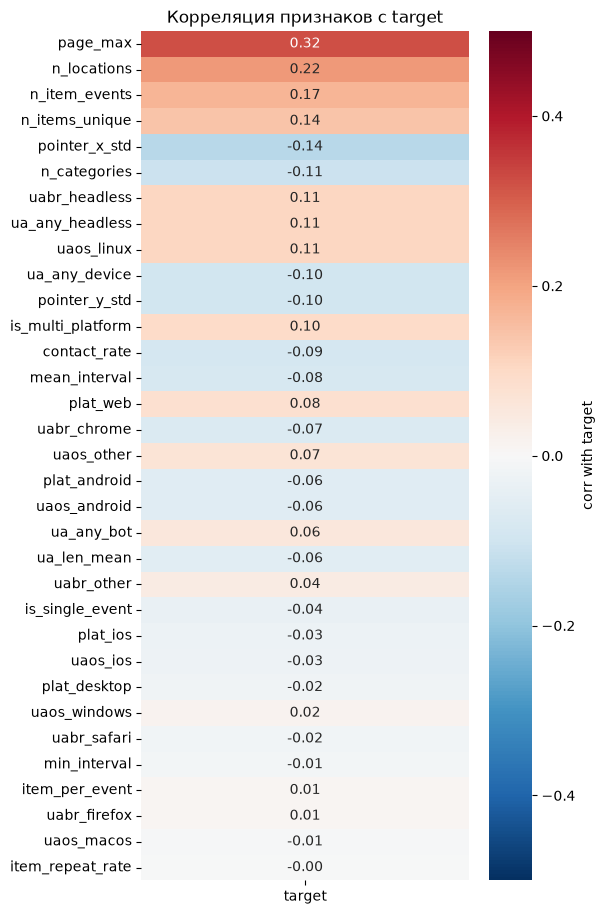

In [95]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr_with_target = (num_df.corr()['target']
                          .drop('target')
                          .sort_values(key=abs, ascending=False))

plt.figure(figsize=(6, max(6, len(corr_with_target) * 0.28)))
sns.heatmap(
    corr_with_target.to_frame(),
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
    cbar_kws={'label': 'corr with target'}
)
plt.title('Корреляция признаков с target')
plt.tight_layout()
plt.show()

#### Удалим дубликаты

In [96]:
drop_cols = {
    'cookie_id',
    'target',
    'window_start_ts',
    'window_end_ts',
    'cookie_created_at',
    'platform_main',
    'ua_os_mode',
    'ua_browser_mode',
}
feat_cols = [
    c for c in train.columns
    if c not in drop_cols and pd.api.types.is_numeric_dtype(train[c])
]

In [97]:
corr_mat = X_train[feat_cols].corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
dups = [(c1, c2, upper.loc[c1, c2])
        for c1 in upper.index for c2 in upper.columns
        if upper.loc[c1, c2] > 0.95]
print("Дубликаты:", dups)

Дубликаты: [('plat_android', 'uaos_android', np.float64(1.0)), ('ua_any_headless', 'uaos_linux', np.float64(1.0)), ('ua_any_headless', 'uabr_headless', np.float64(1.0)), ('uaos_linux', 'uabr_headless', np.float64(1.0)), ('n_items_unique', 'n_item_events', np.float64(0.9765511259554183))]


У нас есть дубликаты, обработаем их

In [98]:
drop_cols_dup = ['uaos_android', 'uaos_linux', 'ua_any_headless', 'n_items_unique', 'n_item_events']

In [99]:
feat_cols_clean = [c for c in feat_cols if c not in drop_cols_dup]

In [100]:
X_train = X_train[feat_cols_clean]
X_val = X_val[feat_cols_clean]

Попробуем обучить с новыми признаками

In [101]:
models = {
    'LogReg': make_pipeline(
                  StandardScaler(),
                  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    'RF': RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight='balanced', random_state=42),
    'GB': GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8, min_samples_leaf=5, random_state=42),
}

results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    results.append(evaluate(name, m, X_val, y_val))

res_df = pd.DataFrame(results).set_index('model').round(4)
print(res_df.sort_values('P@R>=0,7', ascending=False))

        P@R>=0,7  PR-AUC  ROC-AUC
model                            
RF        0.4891  0.6162   0.8946
GB        0.4375  0.6287   0.8946
LogReg    0.2779  0.4434   0.8506


In [102]:
models = {
    'RF': RandomForestClassifier(n_estimators=200, min_samples_leaf=3, class_weight='balanced', random_state=42),
    'GB': GradientBoostingClassifier(n_estimators=500, learning_rate=0.025, max_depth=3, subsample=0.6, min_samples_leaf=4, random_state=42),
}

results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    results.append(evaluate(name, m, X_val, y_val))

res_df = pd.DataFrame(results).set_index('model').round(4)
print(res_df.sort_values('P@R>=0,7', ascending=False))

       P@R>=0,7  PR-AUC  ROC-AUC
model                           
GB       0.5411  0.6275   0.8988
RF       0.4978  0.6160   0.8954


Чтобы попробовать улучшить качество модели я сделала меньше шаг переобучения, меньше глубину дерева. Так как у нас дисбаланс, то важно не переобучить модель.

Результаты получились немного лучше, теперь преобладает GB

In [103]:
final_model = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.025,
    max_depth=3,
    subsample=0.6,
    min_samples_leaf=4,
    random_state=42,
)

In [104]:
final_model.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.025
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (

## Запуск на тестовой выборке

### Подготовка данных

In [106]:
test = pd.read_csv('data/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])

In [107]:
test_result = pd.merge(test, events, on='cookie_id', how="inner")

In [108]:
test_result.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21,2026-04-20 13:38:51,200,item_view,desktop,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1023358.0,uslugi,sankt-peterburg,pro,NaN,NaN,448.0,182.0
1,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21,2026-04-20 17:48:02,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1029995.0,uslugi,makhachkala,private,NaN,NaN,NaN,NaN
2,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21,2026-04-20 21:35:17,200,item_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1009634.0,rabota,ufa,pro,NaN,NaN,784.0,155.0
3,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21,2026-04-20 15:41:26,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1037250.0,rabota,chelyabinsk,private,NaN,NaN,892.0,650.0
4,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21,2026-04-20 20:11:06,100,search_results_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,NaN,rabota,ufa,NaN,работа курьером,1.0,1496.0,111.0


In [109]:
test_result = test_result[
    (test_result['event_ts'] >= test_result['window_start_ts']) & (test_result['event_ts'] < test_result['window_end_ts'])
]

In [110]:
test_result = test_result.sort_values(['cookie_id', 'event_ts'])

In [111]:
test_result.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
53527,ck_00013fdfa0bd37dd,2025-10-09 18:49:47,2026-04-24,2026-04-25,2026-04-24 18:41:16,210,photo_swipe,ANDROID,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...,1012349.0,rabota,moskva,private,NaN,NaN,NaN,NaN
53528,ck_00013fdfa0bd37dd,2025-10-09 18:49:47,2026-04-24,2026-04-25,2026-04-24 19:16:53,200,item_view,android,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...,1054355.0,rabota,moskva,private,NaN,NaN,NaN,NaN
53532,ck_00013fdfa0bd37dd,2025-10-09 18:49:47,2026-04-24,2026-04-25,2026-04-24 19:16:54,210,photo_swipe,ANDROID,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...,1015683.0,detskie_tovary,habarovsk,pro,NaN,NaN,NaN,NaN
53529,ck_00013fdfa0bd37dd,2025-10-09 18:49:47,2026-04-24,2026-04-25,2026-04-24 19:17:05,200,item_view,android,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...,1028622.0,avtomobili,moskva,private,NaN,NaN,NaN,NaN
53534,ck_00013fdfa0bd37dd,2025-10-09 18:49:47,2026-04-24,2026-04-25,2026-04-24 20:05:05,500,login,android,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Создаем признаки

#### Интервал времени

In [112]:
test_result['time_diff'] = (
    test_result.groupby('cookie_id')['event_ts']
         .diff()
         .dt.total_seconds()
)

interval_stats_te = (
    test_result
    .groupby('cookie_id')['time_diff']
    .agg(
        mean_interval='mean',
        min_interval='min'
    )
    .reset_index()
)

In [113]:
test_result = test_result.merge(interval_stats_te, on='cookie_id', how='left')

In [114]:
test = pd.merge(test, interval_stats_te[['mean_interval', 'min_interval', 'cookie_id']], on='cookie_id', how="inner")

In [115]:
test_result = test_result.drop(labels = ['cookie_created_at', 'window_end_ts'], axis = 1)

#### Обработка event_name

In [116]:
contact_events = {'favorite_add', 'contact_phone_show', 'contact_chat_open', 'contact_message_sent', 'login'}

In [117]:
test_result['is_contact'] = np.where(test_result.event_name.isin(contact_events), 1, 0)

In [118]:
test_result = test_result.drop(labels = 'event_name', axis = 1)

In [119]:
contact_rate_test = contact_rate_features(test_result, test_result)

In [120]:
test_result = pd.merge(test_result, contact_rate_test[['cookie_id', 'contact_rate']], on='cookie_id', how="inner")

In [121]:
test_result = test_result.drop(labels = 'contact_rate', axis = 1)

In [122]:
test = pd.merge(test, contact_rate_test[['cookie_id', 'contact_rate']], on='cookie_id', how="inner")

In [123]:
test.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,mean_interval,min_interval,contact_rate
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21,555.886076,0.0,0.212500
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21,23.625000,0.0,0.111111
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21,1030.571429,18.0,0.250000
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21,71.375000,4.0,0.111111
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21,80.000000,80.0,0.000000


#### Обработка platform

In [124]:
test_result['platform_n'] = normalize_platform(test_result['platform'])

In [125]:
plat_te = platform_per_cookie(test_result, test)
plat_te.head()

,cookie_id,platform_main,n_platforms,is_multi_platform
0,ck_315fb710a0e371e7,web,2,1
1,ck_a76ee3b3e3e522fd,web,2,1
2,ck_94c9a4d382689e82,android,1,0
3,ck_8eaf9509ad9462a0,web,2,1
4,ck_9a88a5a989cb5bc6,android,1,0


In [126]:
test_result = pd.merge(test_result, plat_te[['platform_main', 'is_multi_platform', 'cookie_id']], on='cookie_id', how="inner")

In [127]:
test_result = test_result.drop(labels = ['platform', 'platform_n'], axis = 1)

In [128]:
test = pd.merge(test, plat_te[['platform_main', 'is_multi_platform', 'cookie_id']], on='cookie_id', how="inner")

In [129]:
platform_dummies = pd.get_dummies(
    test['platform_main'],
    prefix='plat',
    dtype=np.int8
)

test = pd.concat([test, platform_dummies], axis=1)
test.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,mean_interval,min_interval,contact_rate,platform_main,is_multi_platform,plat_android,plat_desktop,plat_ios,plat_web
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21,555.886076,0.0,0.212500,web,1,0,0,0,1
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21,23.625000,0.0,0.111111,web,1,0,0,0,1
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21,1030.571429,18.0,0.250000,android,0,1,0,0,0
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21,71.375000,4.0,0.111111,web,1,0,0,0,1
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21,80.000000,80.0,0.000000,android,0,1,0,0,0


#### Удаление ненужных признаков

In [130]:
test_result = test_result.drop(labels = 'eid', axis = 1)

In [131]:
test_result = test_result.drop(labels = 'seller_type', axis = 1)

#### Обработка item_category

In [132]:
n_cat_te = n_categories_feature(test_result)
n_cat_te.head()

,cookie_id,n_categories
0,ck_00013fdfa0bd37dd,3
1,ck_001e42551cd06e40,2
2,ck_0027b5d4107d65d8,1
3,ck_0027ba644f9ae2cd,2
4,ck_002cf760d173f0f8,1


In [133]:
test_result = pd.merge(test_result, n_cat_te[['n_categories', 'cookie_id']], on='cookie_id', how="inner")
test_result = test_result.drop(labels = 'item_category', axis = 1)

In [134]:
test = pd.merge(test, n_cat_te[['n_categories', 'cookie_id']], on='cookie_id', how="inner")

#### Обработка item_location

In [135]:
loc_te = location_features(test_result)

In [136]:
test_result = pd.merge(test_result, loc_te[['n_locations', 'cookie_id']], on='cookie_id', how="inner")
test_result = test_result.drop(labels = 'item_location', axis = 1)

In [137]:
test = pd.merge(test, loc_te[['n_locations', 'cookie_id']], on='cookie_id', how="inner")

#### Обработка признака user_agent

In [138]:
test_result = test_result.merge(parsed, left_on='user_agent', right_index=True, how='left')
ua_te = ua_features(test_result)
ohe_te = pd.get_dummies(ua_te[['ua_os_mode','ua_browser_mode']], prefix=['uaos','uabr'], dtype=np.int8)
ua_te = pd.concat([ua_te, ohe_te], axis=1)

In [139]:
test_result = pd.merge(test_result, ua_te, on='cookie_id', how="inner")
test_result = test_result.drop(labels = ['user_agent', 'ua_os', 'ua_browser', 'ua_is_bot', 'ua_has_device', 'ua_len', 'ua_n_semicolons'], axis = 1)

In [140]:
test = pd.merge(test, ua_te, on='cookie_id', how="inner")

#### Обработка item_id

In [141]:
item_id_te = item_features(test_result)

In [142]:
test_result = pd.merge(test_result, item_id_te, on='cookie_id', how="inner")

In [143]:
test_result = test_result.drop(labels = 'item_id', axis = 1)

In [144]:
test = pd.merge(test, item_id_te, on='cookie_id', how="inner")

#### Обработка search_query

In [145]:
q_te = query_features(test_result)

In [146]:
test_result = test_result.merge(q_te, on='cookie_id', how='left')

In [147]:
test_result = test_result.drop(labels = ['n_queries',
       'query_len_mean', 'query_words_mean', 'query_single_word_rate',
       'query_per_char', 'query_repeat_rate', 'search_query'], axis = 1)

#### Обработка search_page

In [148]:
pg_te = page_features(test_result)

In [149]:
test_result = pd.merge(test_result, pg_te, on='cookie_id', how="inner")

In [150]:
test_result = test_result.drop(labels = 'search_page', axis = 1)

In [151]:
test = pd.merge(test, pg_te, on='cookie_id', how="inner")

In [152]:
test.head()

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,mean_interval,min_interval,contact_rate,platform_main,is_multi_platform,plat_android,...,uabr_chrome,uabr_firefox,uabr_headless,uabr_other,uabr_safari,n_items_unique,n_item_events,item_per_event,item_repeat_rate,page_max
0,ck_315fb710a0e371e7,2026-02-20 08:52:31,2026-04-20,2026-04-21,555.886076,0.0,0.212500,web,1,0,...,1,0,0,0,0,43,51,0.843137,0.186047,4.0
1,ck_a76ee3b3e3e522fd,2026-01-19 13:42:15,2026-04-20,2026-04-21,23.625000,0.0,0.111111,web,1,0,...,1,0,0,0,0,5,7,0.714286,0.200000,7.0
2,ck_94c9a4d382689e82,2026-04-19 06:28:37,2026-04-20,2026-04-21,1030.571429,18.0,0.250000,android,0,1,...,1,0,0,0,0,6,6,1.000000,0.000000,2.0
3,ck_8eaf9509ad9462a0,2026-01-19 17:18:06,2026-04-20,2026-04-21,71.375000,4.0,0.111111,web,1,0,...,1,0,0,0,0,5,9,0.555556,0.600000,0.0
4,ck_9a88a5a989cb5bc6,2025-11-09 17:25:13,2026-04-20,2026-04-21,80.000000,80.0,0.000000,android,0,1,...,1,0,0,0,0,1,1,1.000000,0.000000,1.0


#### Обработка point_x и point_y

In [153]:
pt_te = pointer_features(test_result)

In [154]:
test_result = test_result.merge(pt_te, on='cookie_id', how='left')

In [155]:
pt_agg_te = pointer_features(test_result)

In [156]:
test_result = test_result.drop(labels = ['pointer_x', 'pointer_y'], axis = 1)

In [157]:
test = test.merge(pt_agg_te, on='cookie_id', how='left')
test[['pointer_x_std','pointer_y_std']] = test[['pointer_x_std','pointer_y_std']].fillna(0)

#### Проверяем оставшиеся пропуски

In [158]:
test.isna().sum()

cookie_id              0
cookie_created_at      0
window_start_ts        0
window_end_ts          0
mean_interval        104
min_interval         104
contact_rate           0
platform_main          0
is_multi_platform      0
plat_android           0
plat_desktop           0
plat_ios               0
plat_web               0
n_categories           0
n_locations            0
ua_os_mode             0
ua_browser_mode        0
ua_any_bot             0
ua_any_device          0
ua_any_headless        0
ua_len_mean            0
uaos_android           0
uaos_ios               0
uaos_linux             0
uaos_macos             0
uaos_other             0
uaos_windows           0
uabr_chrome            0
uabr_firefox           0
uabr_headless          0
uabr_other             0
uabr_safari            0
n_items_unique         0
n_item_events          0
item_per_event         0
item_repeat_rate       0
page_max               0
pointer_x_std          0
pointer_y_std          0
dtype: int64

In [159]:
test['is_single_event'] = test.mean_interval.isna().astype(np.int8)
test['is_single_event'] = test.mean_interval.isna().astype(np.int8)

test[['mean_interval','min_interval']] = test[['mean_interval','min_interval']].fillna(-1)
test[['mean_interval','min_interval']] = test[['mean_interval','min_interval']].fillna(-1)

In [160]:
test = test.drop(labels = ['platform_main', 'ua_os_mode', 'ua_browser_mode'], axis = 1)

In [174]:
test = test.drop(labels = ['n_items_unique', 'n_item_events'], axis = 1)

#### Запускаем модель

In [175]:
cols = ['mean_interval', 'min_interval', 'contact_rate',
       'is_multi_platform', 'plat_android', 'plat_desktop', 'plat_ios',
       'plat_web', 'n_categories', 'n_locations', 'ua_any_bot',
       'ua_any_device', 'ua_len_mean', 'uaos_ios', 'uaos_macos', 'uaos_other',
       'uaos_windows', 'uabr_chrome', 'uabr_firefox', 'uabr_headless',
       'uabr_other', 'uabr_safari',
       'item_per_event', 'item_repeat_rate', 'page_max', 'pointer_x_std',
       'pointer_y_std', 'is_single_event']

In [176]:
final_model = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.025,
    max_depth=3,
    subsample=0.6,
    min_samples_leaf=4,
    random_state=42,
)

In [179]:
final_model.fit(X_train[cols], y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.025
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (

In [163]:
test = test.drop(labels = ['cookie_created_at', 'window_start_ts', 'window_end_ts', 'ua_any_headless', 'uaos_android', 'uaos_linux'], axis = 1)

In [180]:
sub = pd.DataFrame({
    'cookie_id': test.cookie_id,
    'score': final_model.predict_proba(test[cols])[:, 1],
})

In [182]:
sub.to_csv('submission.csv', index=False)
print("Saved:", sub.shape)
print(sub.head())

Saved: (4909, 2)
             cookie_id     score
0  ck_315fb710a0e371e7  0.002776
1  ck_a76ee3b3e3e522fd  0.160551
2  ck_94c9a4d382689e82  0.025148
3  ck_8eaf9509ad9462a0  0.002498
4  ck_9a88a5a989cb5bc6  0.012158
